<a href="https://colab.research.google.com/github/chandinignits-del/ML-Lab-GNITS-2026-27/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Liner Regression**

Linear regression is a statistical method that is used to predict a continuous dependent variable i.e target variable based on one or more independent variables.

This technique assumes a linear relationship between the dependent and independent variables which means the dependent variable changes proportionally with changes in the independent variables.

**Import Libraries:** Necessary libraries like pandas for data handling, numpy for numerical operations, LinearRegression for the model, train_test_split for data splitting, and matplotlib.pyplot for visualization are imported. Create Dataset: A simple DataFrame is created with 'YearsExperience' as the independent variable and 'Salary' as the dependent variable.

**Prepare Data:** The independent variable X and dependent variable y are extracted from the DataFrame. X is kept as a DataFrame (or 2D array) as required by scikit-learn.

**Split Data:** The dataset is divided into training and testing sets using train_test_split. This allows the model to be trained on one portion of the data and evaluated on unseen data, preventing overfitting.

**Train Model:** An instance of LinearRegression is created and then trained using the fit() method on the training data (X_train, y_train).

**Make Predictions:** The trained model's predict() method is used to generate salary predictions for the X_test data.

**Evaluate Model:** Mean Squared Error (MSE) and R-squared are calculated to assess the model's performance. MSE measures the average squared difference between actual and predicted values, while R-squared indicates the proportion of variance in the dependent variable predictable from the independent variable(s). The model's intercept and coefficient (slope) are also printed.

**Visualize Results:**A scatter plot shows the actual salaries in the test set, and a red line represents the linear regression model's predictions, illustrating the learned relationship.

Mean Squared Error: 49830096.86
R-squared: 0.90
Model Intercept: 25321.58
Model Coefficient (Slope): 9423.82


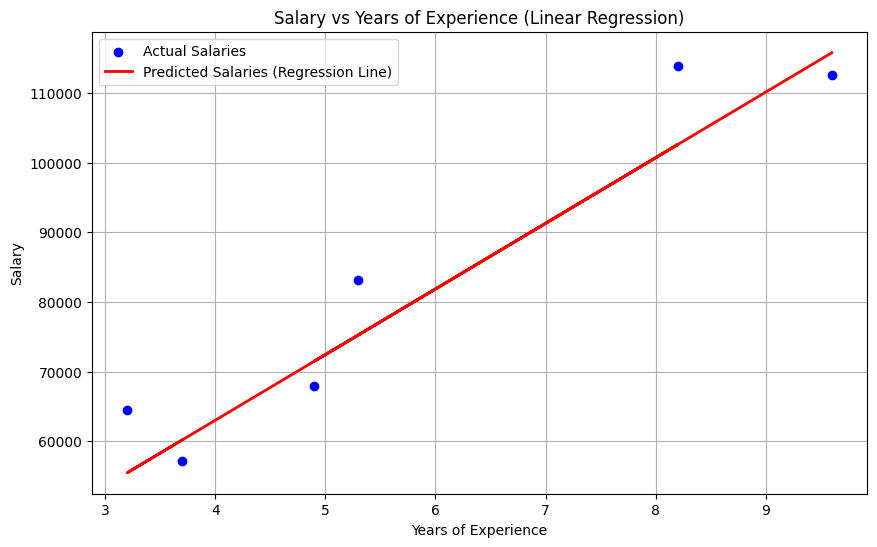

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Create a sample dataset
# Let's consider a simple relationship between 'YearsExperience' and 'Salary'
data = {
    'YearsExperience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7, 3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0, 6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5],
    'Salary': [39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189, 63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940, 91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872]
}
df = pd.DataFrame(data)

# 2. Prepare the data for the model
X = df[['YearsExperience']]  # Independent variable (features)
y = df['Salary']             # Dependent variable (target)

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = model.predict(X_test)

# 6. Evaluate the model (optional, but good practice)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")
print(f"Model Intercept: {model.intercept_:.2f}")
print(f"Model Coefficient (Slope): {model.coef_[0]:.2f}")

# 7. Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Salaries')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Salaries (Regression Line)')
plt.title('Salary vs Years of Experience (Linear Regression)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()


**Locally Weighted Linear Regression (LWLR)** is a non-parametric machine learning algorithm where a distinct local model is fit for every specific query point. Instead of calculating a global boundary, it assigns higher weights to training data points that are closer to the target query point using a Gaussian kernel function.

• **No Training Phase:** LWLR is a lazy learner (similar to k-Nearest Neighbors). It does not calculate parameters until you explicitly ask it to predict a new point.

• **Computational Cost:** Because it relies on all training observations to perform a new matrix inversion for each unique query point, it can be computationally expensive on massive datasets.

• **Hyperparameter Tuning:** The parameter tau (\(\tau \)) controls the bandwidth. Setting it too low will capture noise (overfitting), while setting it too high behaves just like ordinary global linear regression (underfitting)

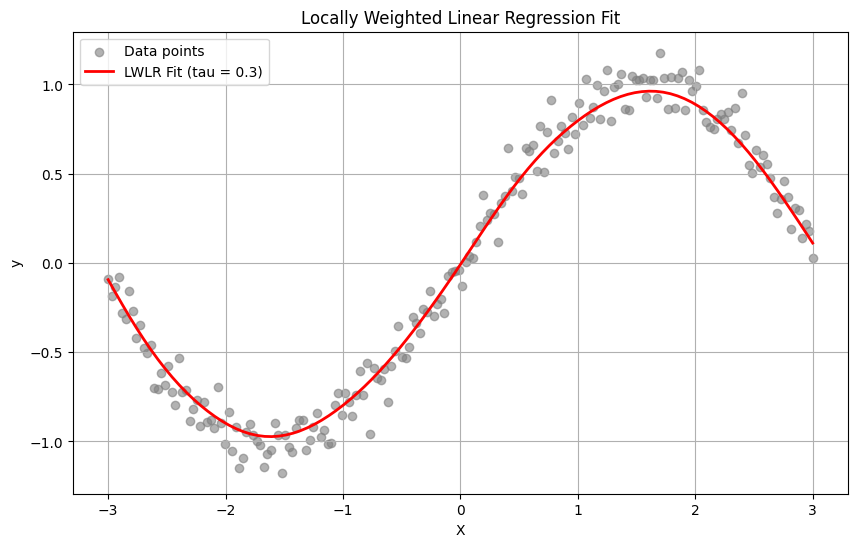

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Gaussian Kernel to calculate weights
def get_weight_matrix(query_point, X, tau):
    """
    Calculates a diagonal weight matrix for a given query point.
    Higher weights are assigned to training points closer to the query point.
    """
    m = X.shape[0]
    W = np.eye(m) # Initialize as an identity matrix

    for i in range(m):
        diff = query_point - X[i]
        # Gaussian kernel formula: w(i) = exp(-||x(i) - x||^2 / (2 * tau^2))
        W[i, i] = np.exp(np.dot(diff, diff.T) / (-2.0 * (tau ** 2)))

    return W

# 2. Predict the target value for a specific query point
def predict(X, y, query_point, tau):
    """
    Fits a local linear regression model for a single query point and returns its prediction.
    """
    # Number of training samples
    m = X.shape[0]

    # Add bias term (column of 1s) to the feature matrix
    X_biased = np.append(X, np.ones((m, 1)), axis=1)

    # Prepare the query point by adding a 1 for its bias term
    query_biased = np.array([query_point, 1.0], dtype=object)

    # Obtain the localized weight matrix
    W = get_weight_matrix(query_biased[:-1], X, tau)

    # Calculate local parameter theta using the normal equation: inv(X^T * W * X) * X^T * W * y
    # np.linalg.pinv is safer to use to prevent singular matrix errors
    theta = np.linalg.pinv(X_biased.T @ W @ X_biased) @ (X_biased.T @ W @ y)

    # Make the prediction: dot product of query point and theta
    prediction = np.dot(query_biased, theta)
    return prediction

# 3. Wrapper function to generate predictions across an evaluation space
def fit_data(X, y, evaluation_points, tau):
    """
    Iterates over all evaluation points to build the non-linear fitted curve.
    """
    predictions = []
    for point in evaluation_points:
        pred = predict(X, y, point, tau)
        predictions.append(pred)
    return np.array(predictions)

# ==========================================
# TEST IMPLEMENTATION WITH GENERATED DATA
# ==========================================
if __name__ == "__main__":
    # Generate noisy non-linear data (Sine Wave)
    np.random.seed(42)
    X = np.linspace(-3, 3, 200).reshape(-1, 1)
    y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

    # Define evaluation space for plotting the smooth curve
    X_eval = np.linspace(-3, 3, 100)

    # Test different values of the smoothing bandwidth parameter (tau)
    # A smaller tau creates a tighter fit (higher variance), larger tau smooths it out (higher bias)
    tau_value = 0.3
    y_pred = fit_data(X, y, X_eval, tau_value)

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='gray', alpha=0.6, label='Data points')
    plt.plot(X_eval, y_pred, color='red', linewidth=2, label=f'LWLR Fit (tau = {tau_value})')
    plt.title('Locally Weighted Linear Regression Fit')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()


Slope: 0.05000000000000002
Intercept: 9.999999999999972
Predicted price for 1400 sq.ft: 80.0 Lakhs


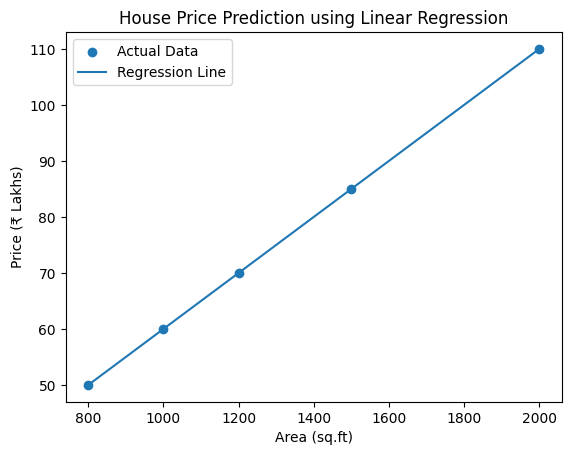

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Dataset
X = np.array([800, 1000, 1200, 1500, 2000]).reshape(-1, 1)
Y = np.array([50, 60, 70, 85, 110])

# Create model
model = LinearRegression()

# Train the model
model.fit(X, Y)

# Predict prices
Y_pred = model.predict(X)

# Display slope and intercept
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

# Predict for a new house
area = np.array([[1400]])
price = model.predict(area)

print("Predicted price for 1400 sq.ft:",
      round(price[0], 2), "Lakhs")

# Plot
plt.scatter(X, Y, label="Actual Data")
plt.plot(X, Y_pred, label="Regression Line")

plt.xlabel("Area (sq.ft)")
plt.ylabel("Price (₹ Lakhs)")
plt.title("House Price Prediction using Linear Regression")
plt.legend()
plt.show()